## Logistic regression summary

A logistic regression pipeline was fitted using the training dataset.

The pipeline:

- imputed missing BMI values using the training-set median
- standardised age, BMI, and encounter count
- retained hypertension as a binary 0/1 predictor
- one-hot encoded gender
- predicted documented diabetes

Model performance was evaluated on the held-out test dataset using accuracy,
precision, recall, F1 score, ROC AUC, and a confusion matrix.

The resulting coefficients describe predictive associations after accounting
for the other model features. They should not be interpreted as evidence of
causal relationships.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [2]:
project_root = Path.cwd().parent
processed_data_dir = project_root / "data" / "processed"

print(project_root)
print(processed_data_dir)

c:\Users\MiGoreng\OneDrive\Documents\GitHub\healthcare-analytics-platform
c:\Users\MiGoreng\OneDrive\Documents\GitHub\healthcare-analytics-platform\data\processed


In [3]:
X_train = pd.read_csv(processed_data_dir / "X_train.csv")
X_test = pd.read_csv(processed_data_dir /"X_test.csv")

y_train = pd.read_csv(processed_data_dir / "y_train.csv").squeeze()
y_test = pd.read_csv(processed_data_dir / "y_test.csv").squeeze()

In [4]:
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")

Training data shape: (4034, 5)
Test data shape: (1730, 5)
Training target shape: (4034,)
Test target shape: (1730,)


In [5]:
numeric_features = [
    "age",
    "bmi",
    "encounter_count",
]

binary_features = [
    "hypertension",
]

categorical_features = [
    "gender",
]

In [6]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

In [7]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            )
        )
    ]
)

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [9]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=123,
                n_jobs=-1
            )
        )
    ]
)

In [10]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['age','gender','bmi','encounter_count','hypertension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

In [11]:
y_pred_rf = random_forest_model.predict(X_test)

In [12]:
y_pred_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [13]:
prediction_preview = pd.DataFrame({
    "actual": y_test.iloc[:10].values,
    "predicted_class": y_pred_rf[:10],
    "predicted_probability": y_pred_proba_rf[:10]
})

prediction_preview

,actual,predicted_class,predicted_probability
0,1,1,0.653333
1,1,0,0.316667
2,1,0,0.150000
3,0,0,0.443333
4,0,0,0.186667
5,0,0,0.000000
6,1,1,0.963333
7,0,1,0.540000
8,1,1,0.540000
9,1,0,0.300000


In [14]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

In [15]:
random_forest_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 score",
        "ROC AUC"
    ],
    "Value": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

random_forest_metrics["Value"] = (
    random_forest_metrics["Value"].round(3)
)

random_forest_metrics

,Metric,Value
0,Accuracy,0.746
1,Precision,0.686
2,Recall,0.739
3,F1 score,0.711
4,ROC AUC,0.838


In [18]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "No diabetes",
            "Diabetes"
        ]
    )
)

              precision    recall  f1-score   support

 No diabetes       0.80      0.75      0.77       998
    Diabetes       0.69      0.74      0.71       732

    accuracy                           0.75      1730
   macro avg       0.74      0.75      0.74      1730
weighted avg       0.75      0.75      0.75      1730



In [19]:
rf_cm = confusion_matrix(y_test, y_pred_rf)

rf_cm

array([[750, 248],
       [191, 541]])

In [20]:
rf_tn, rf_fp, rf_fn, rf_tp = rf_cm.ravel()

print(f"True negatives:  {rf_tn}")
print(f"False positives: {rf_fp}")
print(f"False negatives: {rf_fn}")
print(f"True positives:  {rf_tp}")

True negatives:  750
False positives: 248
False negatives: 191
True positives:  541


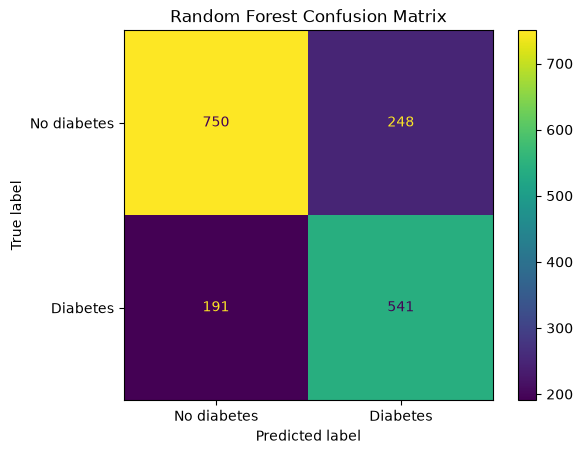

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=[
        "No diabetes",
        "Diabetes"
    ],
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

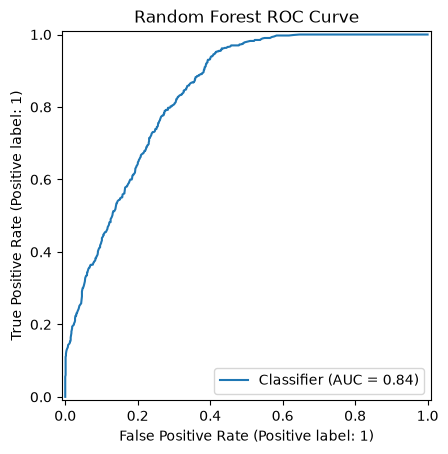

In [22]:
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba_rf
)

plt.title("Random Forest ROC Curve")
plt.show()

In [23]:
feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_names

array(['numeric__age', 'numeric__bmi', 'numeric__encounter_count',
       'binary__hypertension', 'categorical__gender_M'], dtype=object)

In [24]:
rf_classifier = (
    random_forest_model
    .named_steps["classifier"]
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,numeric__age,0.400446
1,numeric__bmi,0.280086
2,numeric__encounter_count,0.251424
3,binary__hypertension,0.050842
4,categorical__gender_M,0.017202


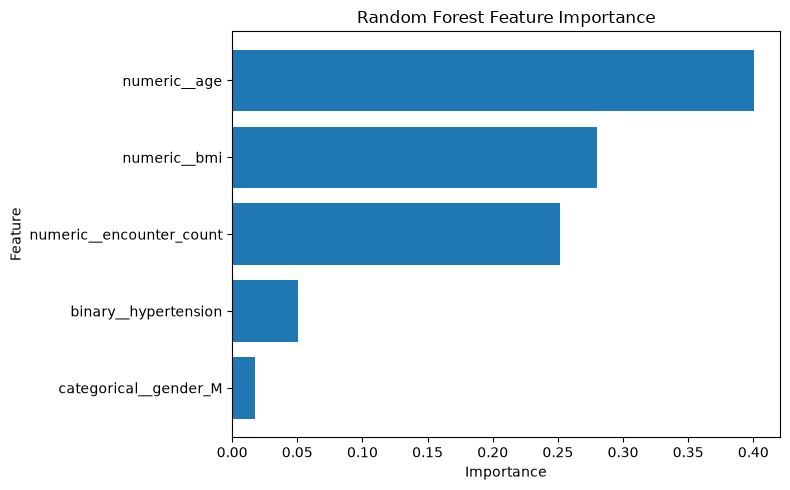

In [25]:
feature_importance_plot = (
    feature_importance
    .sort_values("Importance")
)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance_plot["Feature"],
    feature_importance_plot["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [26]:
permutation_result = permutation_importance(
    random_forest_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=123,
    n_jobs=-1
)

In [27]:
permutation_table = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean importance": permutation_result.importances_mean,
    "Standard deviation": permutation_result.importances_std
})

permutation_table = permutation_table.sort_values(
    "Mean importance",
    ascending=False
)

permutation_table

,Feature,Mean importance,Standard deviation
0,age,0.214596,0.009131
3,encounter_count,0.031227,0.006916
4,hypertension,0.019340,0.003633
2,bmi,0.004557,0.006704
1,gender,-0.003584,0.003601


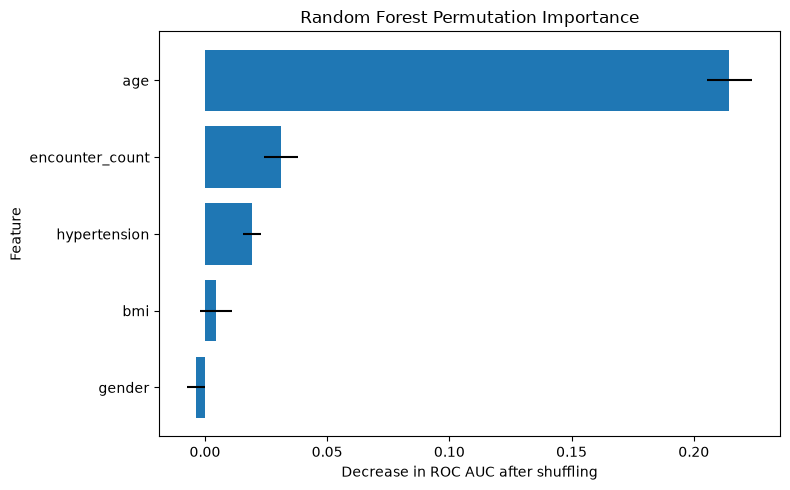

In [28]:
permutation_plot = permutation_table.sort_values(
    "Mean importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    permutation_plot["Feature"],
    permutation_plot["Mean importance"],
    xerr=permutation_plot["Standard deviation"]
)

plt.xlabel("Decrease in ROC AUC after shuffling")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Importance")
plt.tight_layout()
plt.show()

In [29]:
initial_comparison = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "Random forest"
    ],
    "Accuracy": [
        0.75,
        rf_accuracy
    ],
    "Diabetes precision": [
        0.70,
        rf_precision
    ],
    "Diabetes recall": [
        0.72,
        rf_recall
    ],
    "Diabetes F1": [
        0.71,
        rf_f1
    ],
    "ROC AUC": [
        None,
        rf_roc_auc
    ]
})

initial_comparison.round(3)

,Model,Accuracy,Diabetes precision,Diabetes recall,Diabetes F1,ROC AUC
0,Logistic regression,0.750,0.700,0.720,0.710,NaN
1,Random forest,0.746,0.686,0.739,0.711,0.838


In [30]:
model_output_dir = project_root / "outputs" / "models"
model_output_dir.mkdir(parents=True, exist_ok=True)

In [31]:
random_forest_metrics.to_csv(
    model_output_dir / "random_forest_metrics.csv",
    index=False
)

In [32]:
feature_importance.to_csv(
    model_output_dir / "random_forest_feature_importance.csv",
    index=False
)

In [33]:
permutation_table.to_csv(
    model_output_dir / "random_forest_permutation_importance.csv",
    index=False
)

## Random Forest summary

A Random Forest classifier was trained using the same training and test datasets
as the logistic regression model.

The preprocessing pipeline:

- imputed missing BMI values using the training-set median
- retained numeric predictors without standardisation
- retained hypertension as a binary predictor
- one-hot encoded gender

Performance was evaluated using accuracy, precision, recall, F1 score, ROC AUC,
and a confusion matrix.

Feature importance was examined using both the model's impurity-based importance
and permutation importance. These values describe how the fitted model used the
available predictors and should not be interpreted as evidence of causal or
clinical importance.